# Prediccion del marcador: Mexico vs Corea del Sur

## Mundial FIFA 2026 - Grupo A - dos modelos: MCMC y XGBoost

Este notebook predice el **marcador exacto** del partido con dos enfoques y dibuja, para cada uno, la grafica de tres paneles (heatmap de marcadores, probabilidad de resultado y top 10 marcadores).

**Repositorio de datos (GitHub):**
> `martj42/international_results`
> https://github.com/martj42/international_results
> CSV directo: https://raw.githubusercontent.com/martj42/international_results/master/results.csv

**Los dos modelos:**

1. **MCMC bayesiano (Baio-Blangiardo).** Modelo Poisson jerarquico muestreado con PyMC. Para el marcador usamos la *distribucion predictiva posterior*: promediamos la matriz de marcadores sobre todas las muestras, asi el marcador refleja la incertidumbre del modelo.

2. **XGBoost (regresion de goles).** Importante: XGBoost no produce un marcador por si solo, es un metodo de regresion/clasificacion. Para obtener un marcador, entrenamos **dos regresores con objetivo Poisson** (`count:poisson`) que predicen los goles esperados de cada equipo, y convertimos esos goles en una matriz de marcadores con la distribucion de Poisson. Es el enfoque hibrido de Groll: el machine learning estima las tasas de gol, la estructura de Poisson genera el marcador.


In [1]:
# ============================================================
# CELDA 1: Instalar dependencias
# ============================================================
!pip install pymc xgboost scipy pandas numpy matplotlib seaborn --quiet
print('Dependencias listas')

Dependencias listas


In [2]:
# ============================================================
# CELDA 2: Importar librerias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import poisson
from scipy.optimize import minimize
import pymc as pm
import xgboost as xgb
import warnings, time
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Librerias cargadas')

Librerias cargadas


In [3]:
# ============================================================
# CELDA 3: Descargar dataset desde el repositorio martj42
# ============================================================
REPO = 'martj42/international_results'
url = f'https://raw.githubusercontent.com/{REPO}/master/results.csv'
print(f'Repositorio: {REPO}')
print('Descargando...')
df_raw = pd.read_csv(url)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_all = df_raw[df_raw['home_score'].notna()].copy()
df_all['home_score'] = df_all['home_score'].astype(int)
df_all['away_score'] = df_all['away_score'].astype(int)
print(f'Partidos con marcador: {len(df_all):,}  ({df_all.date.min().date()} a {df_all.date.max().date()})')

Repositorio: martj42/international_results
Descargando...
Partidos con marcador: 49,425  (1872-11-30 a 2026-06-16)


In [4]:
# ============================================================
# CELDA 4: Configuracion
# ============================================================
HOME_TEAM   = 'Mexico'
AWAY_TEAM   = 'South Korea'
ABBR_HOME   = 'MEX'        # abreviacion para las graficas
ABBR_AWAY   = 'KOR'
MATCH_DATE  = pd.Timestamp('2026-06-18')
HOME_IS_HOST = True

DESDE        = pd.Timestamp('2018-01-01')
DESDE_BAYES  = pd.Timestamp('2022-09-01')
HALF_LIFE    = 547
MIN_PARTIDOS_BAYES = 25
MAXG = 7

C_HOME, C_DRAW, C_AWAY = '#006847', '#BDBDBD', '#CD2E3A'   # verde MX, gris empate, rojo KR
print('Partido:', HOME_TEAM, 'vs', AWAY_TEAM, '-', MATCH_DATE.date())

Partido: Mexico vs South Korea - 2026-06-18


In [5]:
# ============================================================
# CELDA 5: Dixon-Coles (sirve de base para las variables de XGBoost)
# ============================================================
def fit_dixon_coles(train, cutoff, half_life=HALF_LIFE):
    train = train.copy()
    train['w'] = 0.5 ** ((cutoff - train['date']).dt.days / half_life)
    teams = sorted(set(train['home_team']) | set(train['away_team']))
    idx = {t:i for i,t in enumerate(teams)}; n = len(teams)
    hi = train['home_team'].map(idx).values; ai = train['away_team'].map(idx).values
    hs = train['home_score'].values; as_ = train['away_score'].values; w = train['w'].values
    lm = (train['neutral']==False).values.astype(float)
    def tau(x,y,l,m,r):
        t=np.ones_like(l)
        a=(x==0)&(y==0);t[a]=1-l[a]*m[a]*r; a=(x==0)&(y==1);t[a]=1+l[a]*r
        a=(x==1)&(y==0);t[a]=1+m[a]*r;       a=(x==1)&(y==1);t[a]=1-r
        return t
    def nll(p):
        at=p[:n]-p[:n].mean(); dn=p[n:2*n]; h=p[2*n]; r=p[2*n+1]
        l=np.exp(at[hi]-dn[ai]+h*lm); m=np.exp(at[ai]-dn[hi])
        t=np.clip(tau(hs,as_,l,m,r),1e-10,None)
        return -(w*(np.log(t)+poisson.logpmf(hs,l)+poisson.logpmf(as_,m))).sum()
    r=minimize(nll,np.concatenate([np.zeros(n),np.zeros(n),[.25,-.05]]),method='L-BFGS-B')
    at=r.x[:n]-r.x[:n].mean()
    return {'att':at,'dfn':r.x[n:2*n],'home':r.x[2*n],'rho':r.x[2*n+1],'idx':idx,'teams':teams}

print('Ajustando Dixon-Coles...')
t0=time.time()
dc = fit_dixon_coles(df_all[(df_all.date>=DESDE)&(df_all.date<MATCH_DATE)], MATCH_DATE)
print(f'Listo en {time.time()-t0:.0f}s')

Ajustando Dixon-Coles...
Listo en 26s


In [6]:
# ============================================================
# CELDA 6: MODELO 1 - MCMC bayesiano (PyMC)
# ============================================================
train_b = df_all[(df_all.date>=DESDE_BAYES)&(df_all.date<MATCH_DATE)]
cnt = pd.concat([train_b.home_team, train_b.away_team]).value_counts()
keep = set(cnt[cnt>=MIN_PARTIDOS_BAYES].index)
tb = train_b[train_b.home_team.isin(keep)&train_b.away_team.isin(keep)]
teams_b = sorted(keep); idxb = {t:i for i,t in enumerate(teams_b)}; nb_ = len(teams_b)
hi = tb.home_team.map(idxb).values; ai = tb.away_team.map(idxb).values
hs = tb.home_score.values; as_ = tb.away_score.values
lm = (tb.neutral==False).values.astype(float)

print('Muestreando MCMC... ~1 min')
t0=time.time()
with pm.Model() as model:
    sa=pm.HalfNormal('sa',1.0); sd=pm.HalfNormal('sd',1.0)
    att=pm.Normal('att',0,sa,shape=nb_); dfn=pm.Normal('dfn',0,sd,shape=nb_)
    home=pm.Normal('home',0.25,0.5); base=pm.Normal('base',0,1)
    ac=att-att.mean(); dc_=dfn-dfn.mean()
    pm.Poisson('gh',pm.math.exp(base+home*lm+ac[hi]-dc_[ai]),observed=hs)
    pm.Poisson('ga',pm.math.exp(base+ac[ai]-dc_[hi]),observed=as_)
    trace=pm.sample(1000,tune=1000,chains=2,cores=2,target_accept=0.9,progressbar=True,random_seed=1)
print(f'MCMC listo en {time.time()-t0:.0f}s')

Muestreando MCMC... ~1 min


Output()

MCMC listo en 36s


In [7]:
# ============================================================
# CELDA 7: MODELO 2 - Variables + regresores XGBoost de goles
# ============================================================
# XGBoost no da un marcador directo: entrenamos dos regresores Poisson que
# predicen los goles esperados de cada equipo, y luego Poisson arma el marcador.
known = set(dc['teams']); idx = dc['idx']
att, dfn, home = dc['att'], dc['dfn'], dc['home']

long=[]
for r in df_all[df_all.date>=DESDE].itertuples():
    long.append((r.date, r.home_team, r.home_score, r.away_score, 1))
    long.append((r.date, r.away_team, r.away_score, r.home_score, 0))
L=pd.DataFrame(long,columns=['date','team','gf','ga','ishome']).sort_values('date')
L['pts']=np.where(L.gf>L.ga,3,np.where(L.gf==L.ga,1,0))
g=L.groupby('team')
L['form5']=g['pts'].transform(lambda s:s.shift().rolling(5,min_periods=1).mean())
L['gf5']=g['gf'].transform(lambda s:s.shift().rolling(5,min_periods=1).mean())
L['ga5']=g['ga'].transform(lambda s:s.shift().rolling(5,min_periods=1).mean())
form={(row.date,row.team,row.ishome):(row.form5,row.gf5,row.ga5) for row in L.itertuples()}

def make_features(h,a,host,date):
    lam=np.exp(att[idx[h]]-dfn[idx[a]]+home*host); mu=np.exp(att[idx[a]]-dfn[idx[h]])
    fh=form.get((date,h,1),(1,1,1)); fa=form.get((date,a,0),(1,1,1))
    return [lam,mu,att[idx[h]]-att[idx[a]],dfn[idx[h]]-dfn[idx[a]],float(host),
            fh[0],fh[1],fh[2],fa[0],fa[1],fa[2]]

rowsX=[]; yh=[]; ya=[]
for r in df_all[df_all.date>=DESDE].itertuples():
    if r.home_team not in known or r.away_team not in known: continue
    host=1.0 if r.neutral==False else 0.0
    f=make_features(r.home_team,r.away_team,host,r.date)
    if any(pd.isna(f)): continue
    rowsX.append(f); yh.append(r.home_score); ya.append(r.away_score)
X=np.array(rowsX); yh=np.array(yh); ya=np.array(ya)

params=dict(objective='count:poisson',n_estimators=300,max_depth=4,
            learning_rate=0.05,subsample=0.8,colsample_bytree=0.8)
reg_home=xgb.XGBRegressor(**params).fit(X,yh)
reg_away=xgb.XGBRegressor(**params).fit(X,ya)
print(f'Regresores XGBoost entrenados con {len(X)} partidos')

Regresores XGBoost entrenados con 7923 partidos


In [8]:
# ============================================================
# CELDA 8: Construir la matriz de marcadores de cada modelo
# ============================================================
host = 1.0 if HOME_IS_HOST else 0.0

# --- MCMC: distribucion predictiva posterior (promedio sobre las muestras) ---
post=trace.posterior
ATT=post['att'].stack(s=('chain','draw')).values
DFN=post['dfn'].stack(s=('chain','draw')).values
HOMEs=np.asarray(post['home'].stack(s=('chain','draw')).values).flatten()
BASEs=np.asarray(post['base'].stack(s=('chain','draw')).values).flatten()
ATTc=ATT-ATT.mean(0,keepdims=True); DFNc=DFN-DFN.mean(0,keepdims=True)
ih,ia=idxb[HOME_TEAM],idxb[AWAY_TEAM]
S=ATT.shape[1]; step=max(1,S//500)
M_mcmc=np.zeros((MAXG,MAXG)); c=0
lam_h_draws=[]; lam_a_draws=[]
for s in range(0,S,step):
    lh=np.exp(BASEs[s]+HOMEs[s]*host+ATTc[ih,s]-DFNc[ia,s])
    la=np.exp(BASEs[s]+ATTc[ia,s]-DFNc[ih,s])
    lam_h_draws.append(lh); lam_a_draws.append(la)
    M_mcmc+=np.outer(poisson.pmf(range(MAXG),lh),poisson.pmf(range(MAXG),la)); c+=1
M_mcmc/=c
lam_h_mcmc=np.mean(lam_h_draws); lam_a_mcmc=np.mean(lam_a_draws)

# --- XGBoost: goles esperados de los regresores -> Poisson ---
feat=np.array(make_features(HOME_TEAM,AWAY_TEAM,host,MATCH_DATE)).reshape(1,-1)
lam_h_xgb=float(reg_home.predict(feat)[0]); lam_a_xgb=float(reg_away.predict(feat)[0])
M_xgb=np.outer(poisson.pmf(range(MAXG),lam_h_xgb),poisson.pmf(range(MAXG),lam_a_xgb))
M_xgb/=M_xgb.sum()

def resumen(M, nombre, lh, la):
    pH=np.tril(M,-1).sum(); pD=np.trace(M); pA=np.triu(M,1).sum()
    mi,mj=np.unravel_index(np.argmax(M),M.shape)
    print(f'\n--- {nombre} ---')
    print(f'Goles esperados:  {HOME_TEAM} {lh:.2f}  -  {la:.2f}  {AWAY_TEAM}')
    print(f'Gana {HOME_TEAM}: {pH*100:.1f}%   Empate: {pD*100:.1f}%   Gana {AWAY_TEAM}: {pA*100:.1f}%')
    print(f'MARCADOR MAS PROBABLE: {HOME_TEAM} {mi}-{mj} {AWAY_TEAM}  ({M[mi,mj]*100:.1f}%)')
    rows=[]
    for i in range(MAXG):
        for j in range(MAXG):
            rs=f'{HOME_TEAM} gana' if i>j else ('Empate' if i==j else f'{AWAY_TEAM} gana')
            rows.append({'Marcador':f'{i}-{j}','Prob (%)':round(M[i,j]*100,2),'Resultado':rs})
    return pd.DataFrame(rows).sort_values('Prob (%)',ascending=False).reset_index(drop=True)

top_mcmc=resumen(M_mcmc,'MCMC bayesiano',lam_h_mcmc,lam_a_mcmc)
print('\nTop 10 marcadores (MCMC):'); print(top_mcmc.head(10).to_string(index=False))
top_xgb=resumen(M_xgb,'XGBoost (regresion de goles)',lam_h_xgb,lam_a_xgb)
print('\nTop 10 marcadores (XGBoost):'); print(top_xgb.head(10).to_string(index=False))


--- MCMC bayesiano ---
Goles esperados:  Mexico 1.67  -  1.10  South Korea
Gana Mexico: 50.3%   Empate: 24.2%   Gana South Korea: 25.3%
MARCADOR MAS PROBABLE: Mexico 1-1 South Korea  (11.3%)

Top 10 marcadores (MCMC):
Marcador  Prob (%)        Resultado
     1-1     11.28           Empate
     1-0     10.56      Mexico gana
     2-1      9.23      Mexico gana
     2-0      8.63      Mexico gana
     0-1      7.11 South Korea gana
     0-0      6.67           Empate
     1-2      6.16 South Korea gana
     3-1      5.19      Mexico gana
     2-2      5.06           Empate
     3-0      4.84      Mexico gana

--- XGBoost (regresion de goles) ---
Goles esperados:  Mexico 1.57  -  0.78  South Korea
Gana Mexico: 56.1%   Empate: 25.4%   Gana South Korea: 18.6%
MARCADOR MAS PROBABLE: Mexico 1-0 South Korea  (15.0%)

Top 10 marcadores (XGBoost):
Marcador  Prob (%)        Resultado
     1-0     14.99      Mexico gana
     2-0     11.76      Mexico gana
     1-1     11.70           Empate
     

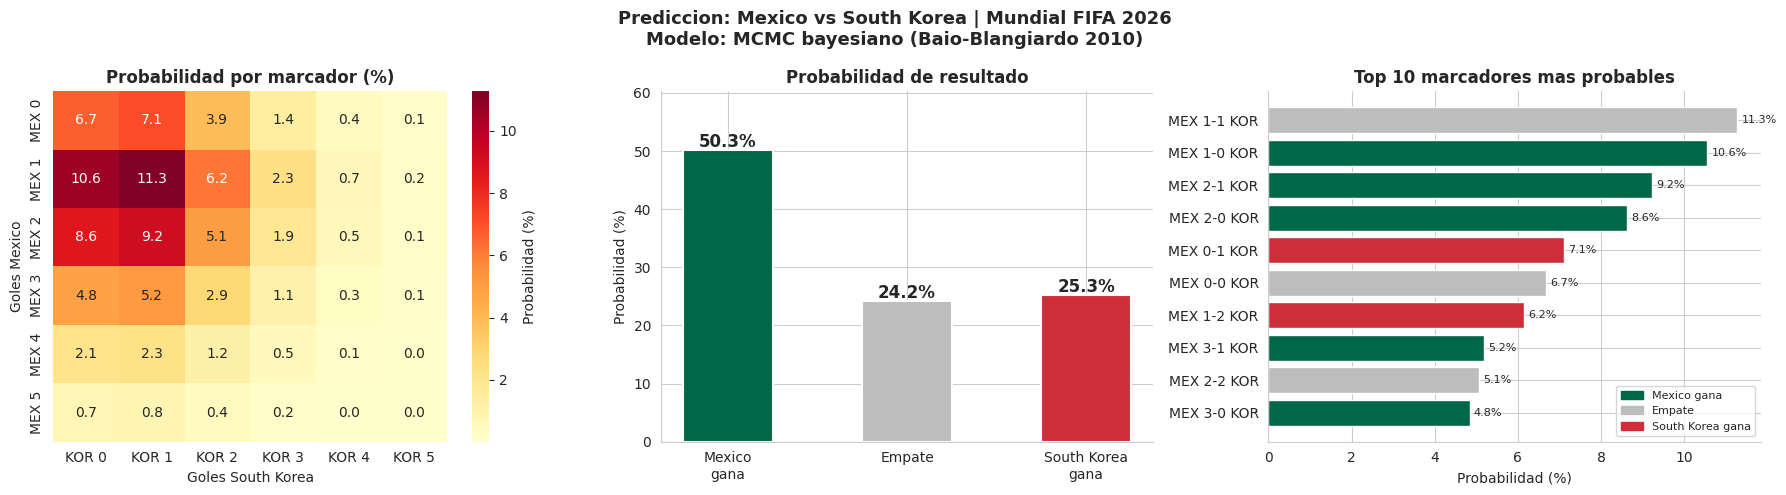

Guardada: marcador_mcmc.png


In [9]:
# ============================================================
# CELDA 9: Grafica de tres paneles (estilo solicitado)
# ============================================================
def plot_3panel(M, top_df, nombre, fname):
    pH=np.tril(M,-1).sum(); pD=np.trace(M); pA=np.triu(M,1).sum()
    fig,axes=plt.subplots(1,3,figsize=(18,5))
    fig.suptitle(f'Prediccion: {HOME_TEAM} vs {AWAY_TEAM} | Mundial FIFA 2026\nModelo: {nombre}',
                 fontsize=13, fontweight='bold')
    # Panel 1: heatmap
    ax=axes[0]
    hd=pd.DataFrame(M[:6,:6]*100,
                    index=[f'{ABBR_HOME} {i}' for i in range(6)],
                    columns=[f'{ABBR_AWAY} {j}' for j in range(6)])
    sns.heatmap(hd,annot=True,fmt='.1f',cmap='YlOrRd',ax=ax,cbar_kws={'label':'Probabilidad (%)'})
    ax.set_title('Probabilidad por marcador (%)',fontweight='bold')
    ax.set_xlabel(f'Goles {AWAY_TEAM}'); ax.set_ylabel(f'Goles {HOME_TEAM}')
    # Panel 2: resultado
    ax=axes[1]
    labs=[f'{HOME_TEAM}\ngana','Empate',f'{AWAY_TEAM}\ngana']; vals=[pH*100,pD*100,pA*100]
    bars=ax.bar(labs,vals,color=[C_HOME,C_DRAW,C_AWAY],width=0.5,edgecolor='white',linewidth=1.5)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+0.5,f'{v:.1f}%',ha='center',fontweight='bold',fontsize=12)
    ax.set_ylim(0,max(vals)*1.2); ax.set_title('Probabilidad de resultado',fontweight='bold')
    ax.set_ylabel('Probabilidad (%)'); ax.spines[['top','right']].set_visible(False)
    # Panel 3: top 10 marcadores
    ax=axes[2]
    t10=top_df.head(10).copy()
    cmap={f'{HOME_TEAM} gana':C_HOME,'Empate':C_DRAW,f'{AWAY_TEAM} gana':C_AWAY}
    labels=[f'{ABBR_HOME} {m} {ABBR_AWAY}' for m in t10['Marcador']]
    colors=[cmap[r] for r in t10['Resultado']]
    ax.barh(labels[::-1], t10['Prob (%)'][::-1], color=colors[::-1])
    for k,v in enumerate(t10['Prob (%)'][::-1]):
        ax.text(v+0.1,k,f'{v:.1f}%',va='center',fontsize=8)
    ax.set_title('Top 10 marcadores mas probables',fontweight='bold'); ax.set_xlabel('Probabilidad (%)')
    ax.legend(handles=[mpatches.Patch(color=C_HOME,label=f'{HOME_TEAM} gana'),
                       mpatches.Patch(color=C_DRAW,label='Empate'),
                       mpatches.Patch(color=C_AWAY,label=f'{AWAY_TEAM} gana')],
              loc='lower right',fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.savefig(fname,dpi=150,bbox_inches='tight'); plt.show()
    print(f'Guardada: {fname}')

plot_3panel(M_mcmc, top_mcmc, 'MCMC bayesiano (Baio-Blangiardo 2010)', 'marcador_mcmc.png')

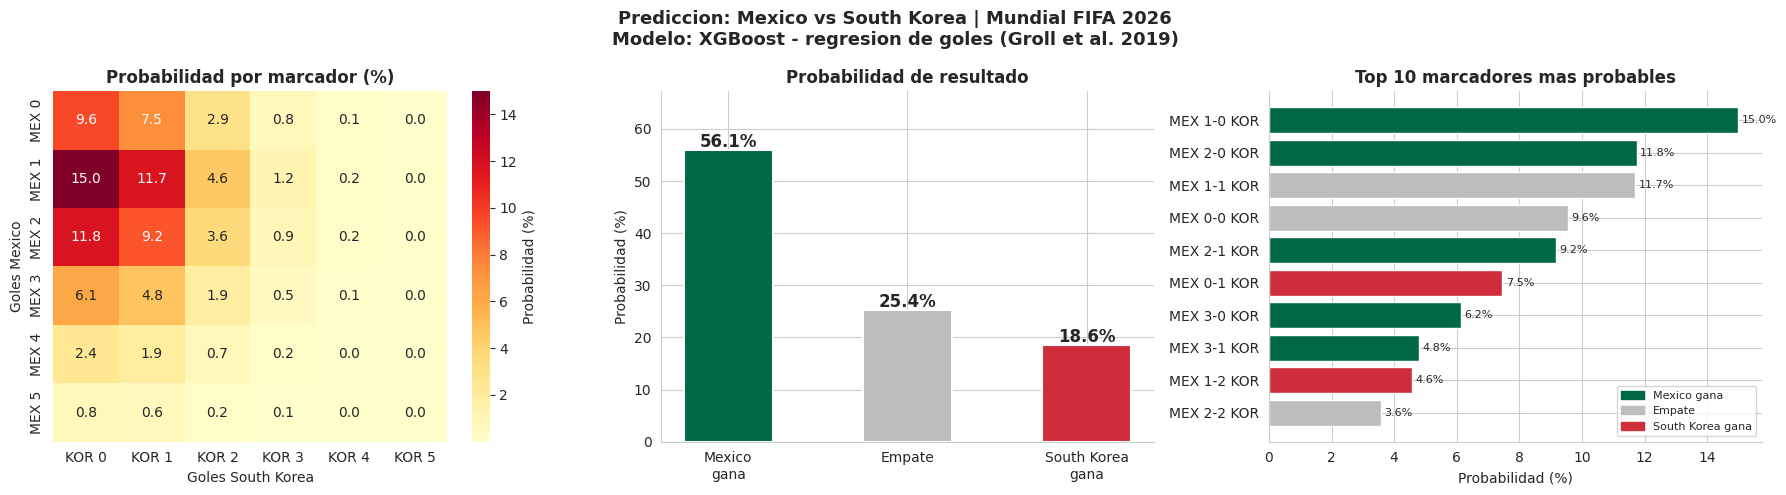

Guardada: marcador_xgboost.png


In [10]:
# ============================================================
# CELDA 10: Grafica de tres paneles - XGBoost
# ============================================================
plot_3panel(M_xgb, top_xgb, 'XGBoost - regresion de goles (Groll et al. 2019)', 'marcador_xgboost.png')

In [11]:
# ============================================================
# CELDA 11: Resumen
# ============================================================
def ml(M):
    mi,mj=np.unravel_index(np.argmax(M),M.shape); return mi,mj,M[mi,mj]*100
m1=ml(M_mcmc); m2=ml(M_xgb)
print('='*58)
print(f'  MARCADOR MAS PROBABLE: {HOME_TEAM} vs {AWAY_TEAM}')
print('='*58)
print(f'  MCMC bayesiano:  {HOME_TEAM} {m1[0]}-{m1[1]} {AWAY_TEAM}   ({m1[2]:.1f}%)')
print(f'  XGBoost:         {HOME_TEAM} {m2[0]}-{m2[1]} {AWAY_TEAM}   ({m2[2]:.1f}%)')
print(f'\n  Repositorio de datos: {REPO}')
print('='*58)
print('\nDISCLAIMER: el futbol tiene aleatoriedad irreducible.')
print('Ejercicio academico, no una recomendacion de apuesta.')

  MARCADOR MAS PROBABLE: Mexico vs South Korea
  MCMC bayesiano:  Mexico 1-1 South Korea   (11.3%)
  XGBoost:         Mexico 1-0 South Korea   (15.0%)

  Repositorio de datos: martj42/international_results

DISCLAIMER: el futbol tiene aleatoriedad irreducible.
Ejercicio academico, no una recomendacion de apuesta.
